## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import logging

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import msml610_utils as ut
import L09_01_reasoning_over_time_utils as time_ut

ut.config_notebook()

# Set plotting style.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
vim support installed: restart the notebook, if needed


Python 3.12.3
Linux 589569fe8102 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 aarch64 aarch64 GNU/Linux


In [2]:
import helpers.hio as hio

import os

dst_dir = "figures"
hio.create_dir(dst_dir, incremental=True)
# cp msml610/tutorials/figures/*.png msml610/lectures_source/figures

# Cell 1

## Cell 1.1: Ground truth

In [26]:
n_samples = 12

# We assume we know the real weight.
ground_truth = 160.0 + np.arange(0, n_samples)

# This is what we measure.
measured_weights = np.array(
    [
        158.0,
        164.2,
        160.3,
        159.9,
        162.1,
        164.6,
        169.6,
        167.4,
        166.4,
        171.0,
        171.2,
        172.6,
    ]
)

idx = pd.date_range("2011-01-01", periods=len(measured_weights))
df = pd.DataFrame(measured_weights.T, index=idx, columns=["measurements"])
df["ground_truth"] = ground_truth

df.head()

,measurements,ground_truth
2011-01-01,158.0,160.0
2011-01-02,164.2,161.0
2011-01-03,160.3,162.0
2011-01-04,159.9,163.0
2011-01-05,162.1,164.0


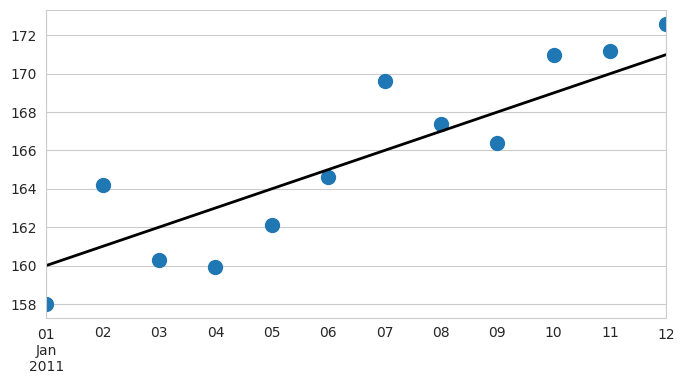

In [27]:
df["measurements"].plot(marker="o", markersize=10, linestyle="None");
df["ground_truth"].plot(color="k", linewidth=2);

plt.savefig(os.path.join(dst_dir, "L09_04_ground_truth.png"))

## Cell 1.2: Knowing gain_rate

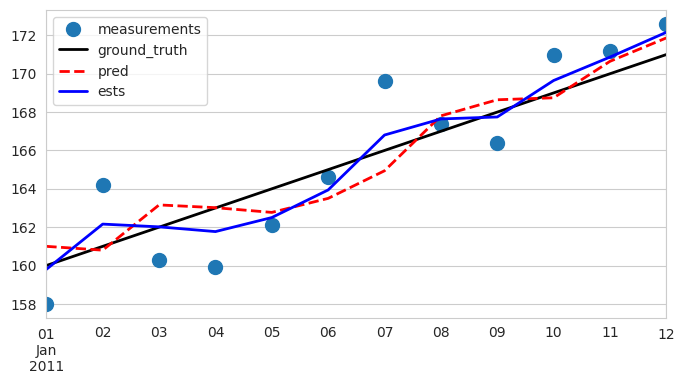

In [28]:
time_step = 1
# This is the blending factor.
weight_scale = 4 / 10.0
# This is the internal model (ground truth).
gain_rate = 1.0
# This is the initial weight.
weight = 160.0

# TODO(ai_gp): Move the following to *_utils and call it cell_1_2_knowning_gain_rate()

ests, preds = time_ut.predict_using_gain_guess(
    weight, measured_weights, gain_rate, weight_scale, time_step
)
# TODO(ai_gp): Use dict and pass plot_prediction_with_params
time_ut.plot_gh_filter_results(measured_weights, preds, ests, ground_truth)
plt.savefig(os.path.join(dst_dir, "L09_04_knowing_gain_rate.png"))

## Cell 1.3: Wrong guess of gain_rate

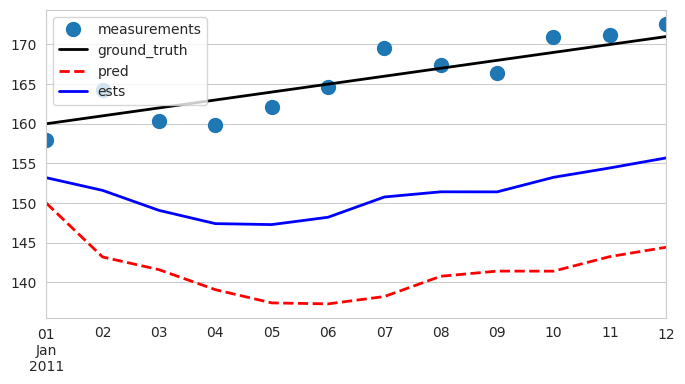

In [29]:
time_step = 1
weight_scale = 4 / 10.0
gain_rate = -10.0
weight = 160.0

# TODO(ai_gp): Move the following to *_utils and call it cell_1_3_wrong_guess_gain_rate()

ests, preds = time_ut.predict_using_gain_guess(
    weight, measured_weights, gain_rate, weight_scale, time_step
)
# TODO(ai_gp): Use dict and pass plot_prediction_with_params
time_ut.plot_gh_filter_results(measured_weights, preds, ests, ground_truth)
plt.savefig(os.path.join(dst_dir, "L09_04_wrong_gain_rate.png"))

In [ ]:
## Cell 1.4: Interactive

In [30]:
# Interactive exploration of gain rate parameters.
time_ut.create_interactive_gain_rate_widget(measured_weights, ground_truth)

## Cell 1.5: Learning gain_rate

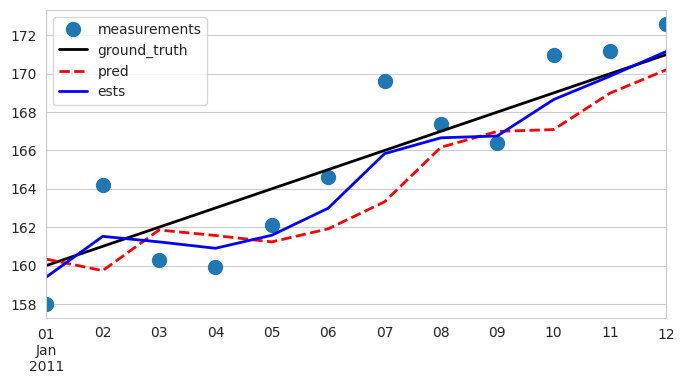

In [8]:
time_step = 1
# Gains for update step.
weight_scale = 4 / 10.0
gain_scale = 1 / 3.0
# Initial guess of gain_rate.
gain_rate = -1.0
weight = 160.0

# TODO(ai_gp): Move the following to *_utils and call it cell_1_5_learning_gain_rate()

ests, preds = time_ut.predict_learning_gain_rate(
    weight, measured_weights, gain_rate, weight_scale, gain_scale, time_step
)
time_ut.plot_gh_filter_results(measured_weights, preds, ests, ground_truth)
plt.savefig(os.path.join(dst_dir, "L09_04_learning_gain_rate.png"))

# Cell 2: Noisy measurements

<Axes: >

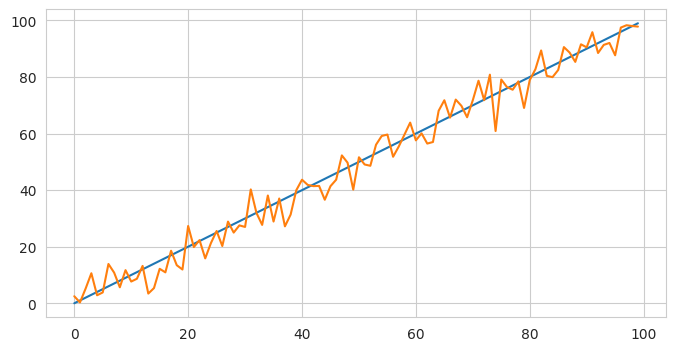

In [9]:
vals, ground_truth = time_ut.gen_linear_noisy_data(
    x0=0, dx=1, count=100, noise_factor=5
)
# TODO(gp): Fix this.
pd.Series(ground_truth).plot()
pd.Series(vals).plot()

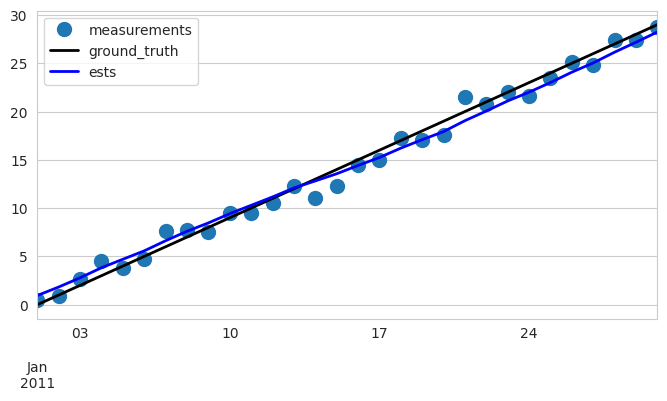

In [10]:
vals, ground_truth = time_ut.gen_linear_noisy_data(
    x0=0, dx=1, count=30, noise_factor=1
)
ests = time_ut.gh_filter(
    data=vals,
    # Initial guesses (actually correct!).
    x0=0,
    dx=1,
    dt=1,
    # g, h params.
    g=0.1,
    h=0.02,
)

preds = None
time_ut.plot_gh_filter_results(vals, preds, ests, ground_truth)

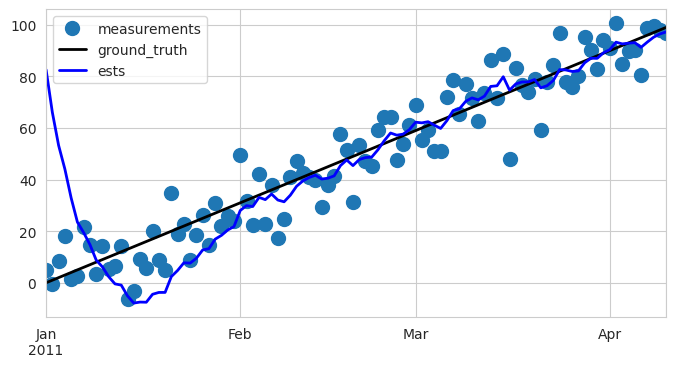

In [11]:
# Wrong initial guess for state.
vals, ground_truth = time_ut.gen_linear_noisy_data(
    x0=0, dx=1, count=100, noise_factor=10
)
ests = time_ut.gh_filter(
    data=vals,
    # Initial guesses (wrong!).
    x0=100,
    dx=2,
    dt=1,
    g=0.2,
    h=0.02,
)
preds = None
time_ut.plot_gh_filter_results(vals, preds, ests, ground_truth)

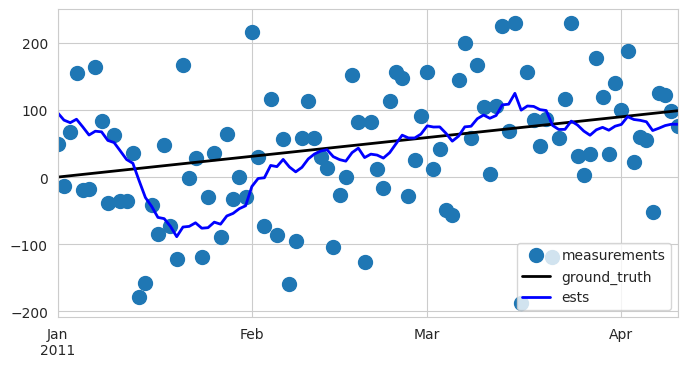

In [12]:
# Extreme noise.
vals, ground_truth = time_ut.gen_linear_noisy_data(
    x0=0, dx=1, count=100, noise_factor=100
)
ests = time_ut.gh_filter(data=vals, x0=100, dx=1, dt=1, g=0.1, h=0.02)
preds = None
time_ut.plot_gh_filter_results(vals, preds, ests, ground_truth)

<Axes: >

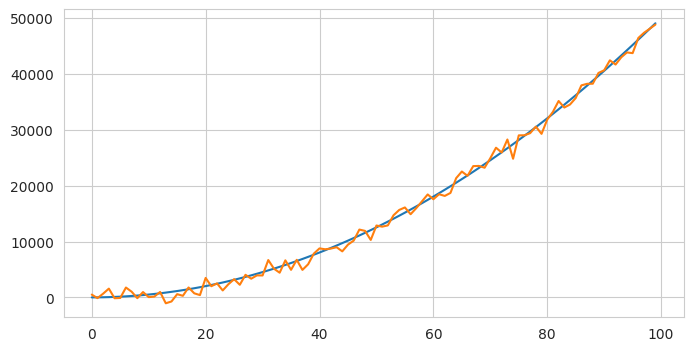

In [13]:
# Non linear ground truth.
vals, ground_truth = time_ut.gen_non_linear_noisy_data(
    x0=0, dx=1, count=100, noise_factor=1000, accel=5
)

# TODO(gp): Fix this.
pd.Series(ground_truth).plot()
pd.Series(vals).plot()

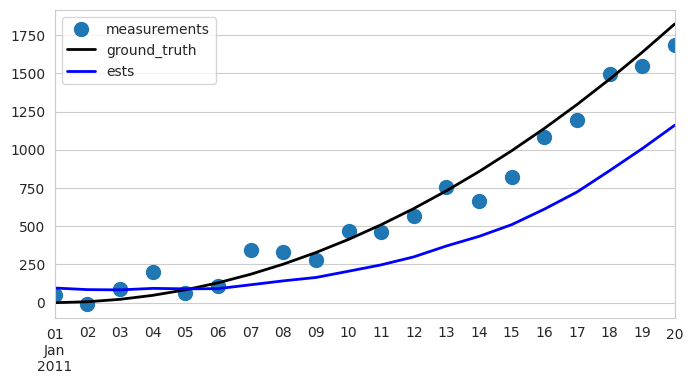

In [14]:
vals, ground_truth = time_ut.gen_non_linear_noisy_data(
    x0=0, dx=1, count=20, noise_factor=100, accel=5
)
ests = time_ut.gh_filter(data=vals, x0=100, dx=1, dt=1, g=0.1, h=0.02)

preds = None
time_ut.plot_gh_filter_results(vals, preds, ests, ground_truth)

## Varying g

<Axes: >

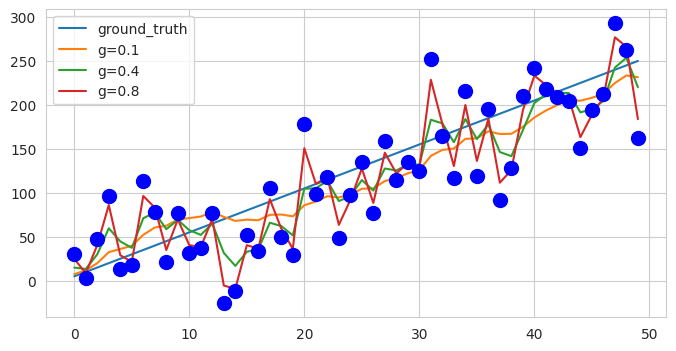

In [15]:
# If g is smaller we follow more our model than the measurements.
# If g is larger we follow more the measurements than our model
# If g is too large we follow the measurements and reject no noise.
np.random.seed(100)
zs, ground_truty = time_ut.gen_linear_noisy_data(
    x0=5, dx=5, count=50, noise_factor=50
)
df = pd.DataFrame(zs)
df.columns = ["measures"]

df["ground_truth"] = ground_truty
df["g=0.1"] = time_ut.gh_filter(data=zs, x0=0.0, dx=5.0, dt=1.0, g=0.1, h=0.01)
df["g=0.4"] = time_ut.gh_filter(data=zs, x0=0.0, dx=5.0, dt=1.0, g=0.4, h=0.01)
df["g=0.8"] = time_ut.gh_filter(data=zs, x0=0.0, dx=5.0, dt=1.0, g=0.8, h=0.01)

df.drop("measures", axis=1).plot()
df["measures"].plot(
    marker="o",
    markersize=10,
    color="b",
    # Hide line.
    linestyle="None",
)

<Axes: >

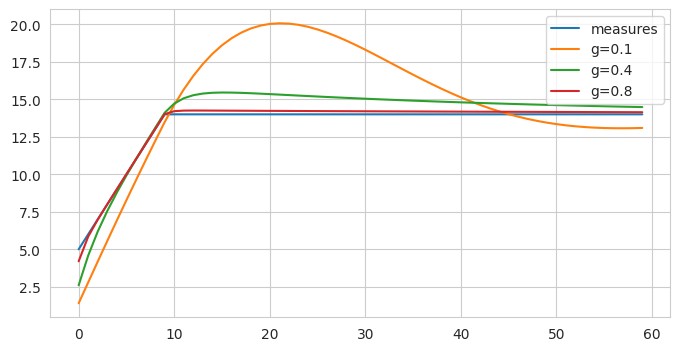

In [16]:
# If g is large we follow more the measures than our model.
zs = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
for i in range(50):
    zs.append(14)
df = pd.DataFrame(zs)
df.columns = ["measures"]

df["g=0.1"] = time_ut.gh_filter(data=zs, x0=0.0, dx=1, dt=1.0, g=0.1, h=0.01)
df["g=0.4"] = time_ut.gh_filter(data=zs, x0=0.0, dx=1, dt=1.0, g=0.4, h=0.01)
df["g=0.8"] = time_ut.gh_filter(data=zs, x0=0.0, dx=1, dt=1.0, g=0.8, h=0.01)

df.plot()

## Varying h
- h affects how much we favor the measurement of $\frac{dx}{dt}$ vs our prediction
- If the signal is varying a lot, then we will react to the transient rapidly

<Axes: >

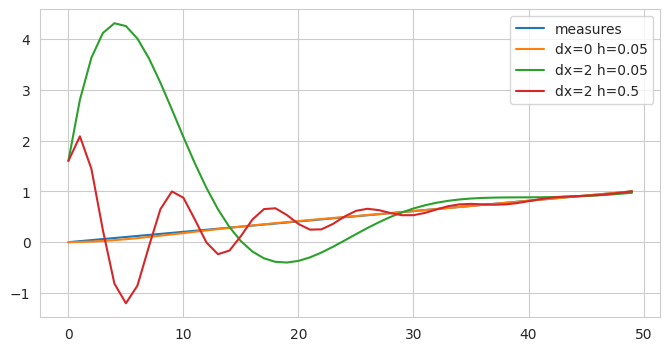

In [17]:
# Go from 0 to 1 in 50 steps (dx = 1 / 50 = 0.02) without noise.
zs = np.linspace(0, 1, 50)
df = pd.DataFrame(zs)
df.columns = ["measures"]

# dx is close to ground truth with small h.
# We track the signal right.
df["dx=0 h=0.05"] = time_ut.gh_filter(data=zs, x0=0, dx=0, dt=1.0, g=0.2, h=0.05)

# dx is wrong, with small h.
# There is big ringing, and we adapt slowly (lower frequency).
df["dx=2 h=0.05"] = time_ut.gh_filter(data=zs, x0=0, dx=2, dt=1.0, g=0.2, h=0.05)

# dx is wrong, with large h.
# Small ringing with higher frequency.
df["dx=2 h=0.5"] = time_ut.gh_filter(data=zs, x0=0, dx=2, dt=1.0, g=0.2, h=0.5)

df.plot()

# Interactice example

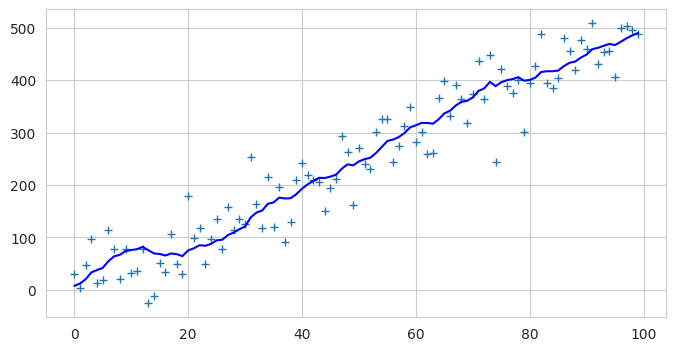

In [18]:
zs1, _ = time_ut.gen_linear_noisy_data(x0=5, dx=5, count=100, noise_factor=50)

fig = None


def interactive_gh(x, dx, g, h):
    global fig
    if fig is not None:
        plt.close(fig)
    fig = plt.figure()
    data = time_ut.gh_filter(data=zs1, x0=x, dx=dx, g=g, h=h)
    plt.scatter(list(range(len(zs1))), zs1, marker="+", lw=1)
    plt.plot(data, color="b")


interactive_gh(0, 5, 0.1, 0.02)

In [19]:
from ipywidgets import interact, FloatSlider

interact(
    interactive_gh,
    x=FloatSlider(value=0.0, min=-200, max=2000, continuous_update=False),
    dx=FloatSlider(value=5.0, min=-50.0, max=50, continuous_update=False),
    g=FloatSlider(
        value=0.1, min=0.01, max=2, step=0.02, continuous_update=False
    ),
    h=FloatSlider(
        value=0.02, min=0.0, max=0.5, step=0.01, continuous_update=False
    ),
)

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='x', max=2000.0, min=-200.0)…

<function __main__.interactive_gh(x, dx, g, h)>

## Discrete Bayes Filter

In [20]:
belief = np.array([1.0 / 10] * 10)
print(belief)

[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]


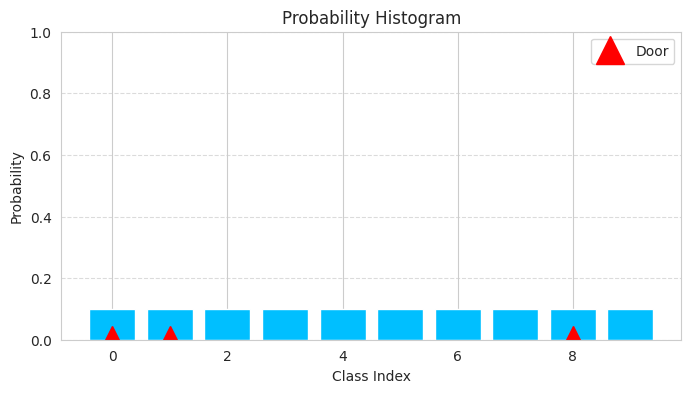

In [21]:
time_ut.plot_dog_in_office_pdf(belief)

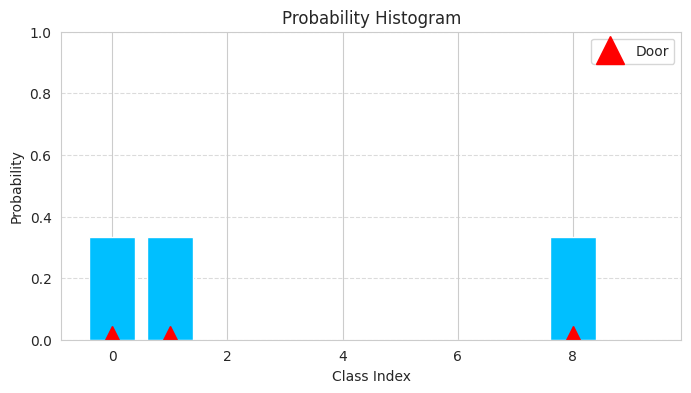

In [22]:
# The sensor says the dog is in front of a door.
belief = np.array([1 / 3, 1 / 3, 0, 0, 0, 0, 0, 0, 1 / 3, 0])
time_ut.plot_dog_in_office_pdf(belief)

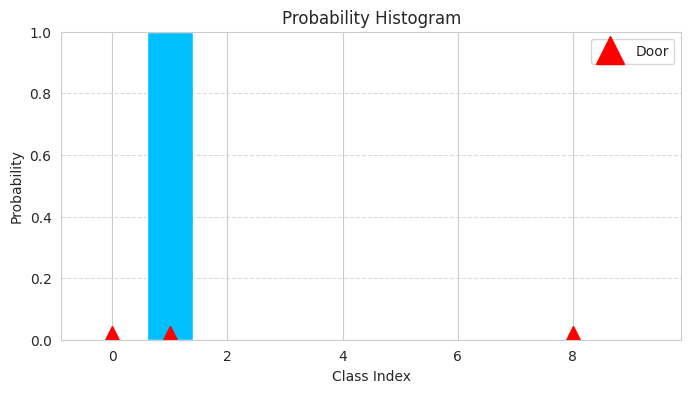

In [23]:
# If the sensor reports "door", "move right", "door", we know that the door is at position 0.
belief = np.array([0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
time_ut.plot_dog_in_office_pdf(belief)

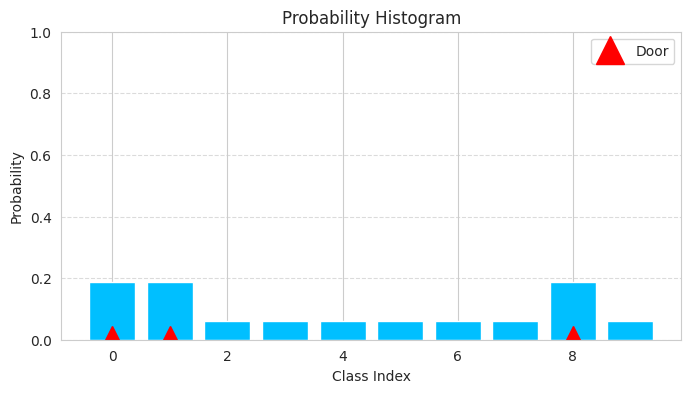

In [24]:
# If sensors are noisy we can't conclude with certainty that we are in front of a door.
# Assume that the sensor is 3x more likely to be right than wrong
# - We need to scale the probability by 3 and then normalize it to sum to 1
belief = np.array(
    [0.188, 0.188, 0.062, 0.062, 0.062, 0.062, 0.062, 0.062, 0.188, 0.062]
)
belief /= sum(belief)
time_ut.plot_dog_in_office_pdf(belief)